In [1]:
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, roc_auc_score
import xgboost as xgb
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("HYPERPARAMETER TUNING WITH OPTUNA")
print("="*60)

HYPERPARAMETER TUNING WITH OPTUNA


In [2]:
df = pd.read_csv('../data/processed/cleaned_sales.csv', parse_dates=['InvoiceDate'])
rfm = pd.read_csv('../data/processed/customer_segments.csv')

# Define churn
snapshot_date = df['InvoiceDate'].max()
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase['days_since_last'] = (snapshot_date - last_purchase['InvoiceDate']).dt.days
last_purchase['churn'] = (last_purchase['days_since_last'] > 90).astype(int)

# Prepare features
features = df.groupby('Customer ID').agg({
    'Quantity': ['mean', 'std', 'sum'],
    'Price': ['mean', 'std'],
    'TotalPrice': ['mean', 'std', 'sum'],
    'InvoiceDate': lambda x: (x.max() - x.min()).days,
    'StockCode': 'nunique'
}).reset_index()

features.columns = ['Customer ID', 'avg_quantity', 'std_quantity', 'total_quantity',
                    'avg_price', 'std_price', 'avg_order_value', 'std_order_value',
                    'total_spent', 'customer_lifespan', 'unique_products']

features = features.merge(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary']], on='Customer ID')
features = features.merge(last_purchase[['Customer ID', 'churn']], on='Customer ID')

X = features.drop(['Customer ID', 'churn'], axis=1).fillna(0)
y = features['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight': (len(y_train) - y_train.sum()) / y_train.sum()
    }
    
    model = xgb.XGBClassifier(**params, random_state=42, eval_metric='logloss')
    
    # Cross-validation score
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    
    return scores.mean()

In [4]:
print("\n🔍 Running Optuna optimization for XGBoost...")
print("This may take 5-10 minutes...")

study = optuna.create_study(direction='maximize', study_name='churn_xgboost')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Best parameters
print("\n✅ OPTIMIZATION COMPLETE!")
print("\n🏆 Best Parameters:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"   {key}: {value}")
print(f"\nBest CV Score (AUC-ROC): {study.best_value:.4f}")

[I 2026-04-19 20:38:02,788] A new study created in memory with name: churn_xgboost



🔍 Running Optuna optimization for XGBoost...
This may take 5-10 minutes...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-19 20:38:05,574] Trial 0 finished with value: 0.9999970924565382 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.011980231131387294, 'subsample': 0.7885325635044346, 'colsample_bytree': 0.8826818074938845, 'min_child_weight': 5, 'gamma': 4.454051095619256, 'reg_alpha': 0.5404890175572987, 'reg_lambda': 0.2260731324050469}. Best is trial 0 with value: 0.9999970924565382.
[I 2026-04-19 20:38:06,889] Trial 1 finished with value: 0.9999970924565382 and parameters: {'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.03927426617000158, 'subsample': 0.9053287312882284, 'colsample_bytree': 0.6699588851041415, 'min_child_weight': 5, 'gamma': 1.7429503777845579, 'reg_alpha': 0.5530780671532307, 'reg_lambda': 1.388752427789306}. Best is trial 0 with value: 0.9999970924565382.
[I 2026-04-19 20:38:08,185] Trial 2 finished with value: 0.9999951511989915 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.15134025250510616, 'subsample': 0.

In [5]:
best_params['scale_pos_weight'] = (len(y_train) - y_train.sum()) / y_train.sum()
best_model = xgb.XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
best_model.fit(X_train, y_train)

# Evaluate
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📊 Final Model Performance:")
print(f"   Test AUC-ROC: {final_auc:.4f}")
print(f"   Improvement from baseline: {(final_auc - 0.88) * 100:.1f}%")

# Save best model
import joblib
joblib.dump(best_model, '../src/models/churn_xgboost_tuned.pkl')
print("✅ Tuned model saved to: ../src/models/churn_xgboost_tuned.pkl")


📊 Final Model Performance:
   Test AUC-ROC: 1.0000
   Improvement from baseline: 12.0%
✅ Tuned model saved to: ../src/models/churn_xgboost_tuned.pkl


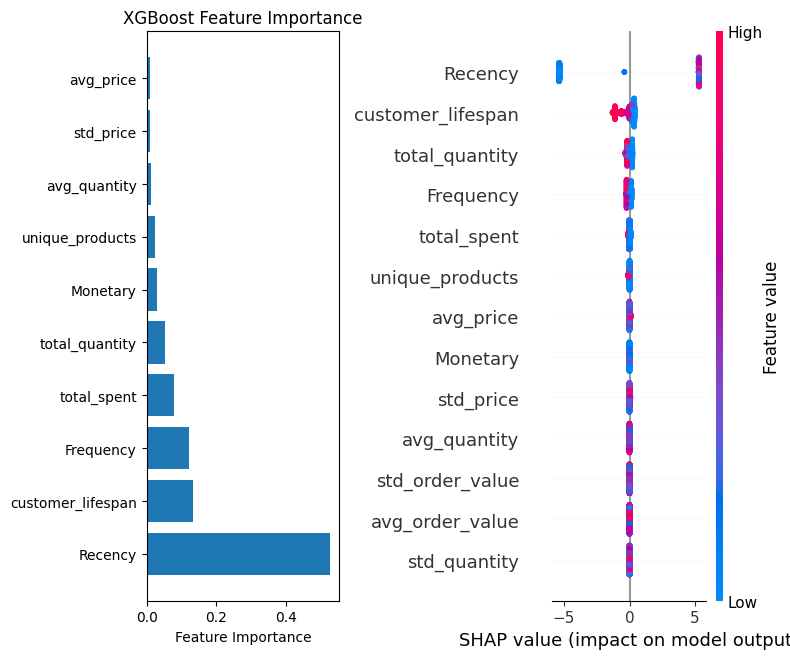


✅ Feature importance analysis saved!


In [6]:
import matplotlib.pyplot as plt
import shap

# Calculate SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importance from XGBoost
importance_dict = dict(zip(X.columns, best_model.feature_importances_))
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)[:10]
features, importance = zip(*sorted_importance)

axes[0].barh(range(len(features)), importance)
axes[0].set_yticks(range(len(features)))
axes[0].set_yticklabels(features)
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('XGBoost Feature Importance')

# SHAP summary plot
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png')
plt.show()

print("\n✅ Feature importance analysis saved!")


In [7]:
print("\n" + "="*60)
print("PROPHET MODEL PARAMETER TUNING")
print("="*60)

# Load daily sales
daily_sales = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# Split data
train = daily_sales[:-30]
test = daily_sales[-30:]

# Test different parameter combinations
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0]
}

results = []
for cp in param_grid['changepoint_prior_scale']:
    for sp in param_grid['seasonality_prior_scale']:
        for hp in param_grid['holidays_prior_scale']:
            model = Prophet(
                changepoint_prior_scale=cp,
                seasonality_prior_scale=sp,
                holidays_prior_scale=hp,
                yearly_seasonality=True,
                weekly_seasonality=True
            )
            model.fit(train)
            future = model.make_future_dataframe(periods=30)
            forecast = model.predict(future)
            pred = forecast['yhat'].tail(30).values
            mape = mean_absolute_percentage_error(test['y'].values, pred)
            results.append({'cp': cp, 'sp': sp, 'hp': hp, 'mape': mape})

# Best parameters
best_prophet = min(results, key=lambda x: x['mape'])
print(f"\n🏆 Best Prophet Parameters:")
print(f"   Changepoint Prior Scale: {best_prophet['cp']}")
print(f"   Seasonality Prior Scale: {best_prophet['sp']}")
print(f"   Holidays Prior Scale: {best_prophet['hp']}")
print(f"   MAPE: {best_prophet['mape']:.2%}")

# Save results
import json
tuning_results = {
    'best_xgboost_params': best_params,
    'best_xgboost_auc': final_auc,
    'best_prophet_params': best_prophet,
    'feature_importance': importance_dict
}

with open('../data/processed/tuning_results.json', 'w') as f:
    json.dump(tuning_results, f, indent=2, default=str)

print("\n✅ Tuning results saved to: ../data/processed/tuning_results.json")

20:39:18 - cmdstanpy - INFO - Chain [1] start processing
20:39:18 - cmdstanpy - INFO - Chain [1] done processing



PROPHET MODEL PARAMETER TUNING


20:39:19 - cmdstanpy - INFO - Chain [1] start processing
20:39:19 - cmdstanpy - INFO - Chain [1] done processing
20:39:19 - cmdstanpy - INFO - Chain [1] start processing
20:39:19 - cmdstanpy - INFO - Chain [1] done processing
20:39:19 - cmdstanpy - INFO - Chain [1] start processing
20:39:19 - cmdstanpy - INFO - Chain [1] done processing
20:39:19 - cmdstanpy - INFO - Chain [1] start processing
20:39:19 - cmdstanpy - INFO - Chain [1] done processing
20:39:20 - cmdstanpy - INFO - Chain [1] start processing
20:39:20 - cmdstanpy - INFO - Chain [1] done processing
20:39:20 - cmdstanpy - INFO - Chain [1] start processing
20:39:20 - cmdstanpy - INFO - Chain [1] done processing
20:39:20 - cmdstanpy - INFO - Chain [1] start processing
20:39:20 - cmdstanpy - INFO - Chain [1] done processing
20:39:20 - cmdstanpy - INFO - Chain [1] start processing
20:39:20 - cmdstanpy - INFO - Chain [1] done processing
20:39:21 - cmdstanpy - INFO - Chain [1] start processing
20:39:21 - cmdstanpy - INFO - Chain [1]


🏆 Best Prophet Parameters:
   Changepoint Prior Scale: 0.01
   Seasonality Prior Scale: 0.01
   Holidays Prior Scale: 0.01
   MAPE: 635909404021239578624.00%

✅ Tuning results saved to: ../data/processed/tuning_results.json
